# Peramalan Kadar NO₂ di Daerah Lumajang

## Latar Belakang
Peningkatan aktivitas industri, transportasi, serta pertumbuhan populasi yang pesat telah menyebabkan peningkatan signifikan terhadap tingkat pencemaran udara di berbagai wilayah. Salah satu polutan udara utama yang menjadi perhatian adalah **Nitrogen Dioksida (NO₂)**, yaitu gas beracun yang dihasilkan terutama dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan kegiatan industri. 

NO₂ memiliki dampak serius terhadap kesehatan manusia, seperti gangguan pernapasan, iritasi paru-paru, serta memperburuk penyakit asma dan bronkitis. Selain itu, NO₂ juga berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan secara keseluruhan. Khusus untuk **Kabupaten Lumajang**, faktor geografis di mana wilayahnya dikelilingi pegunungan serta adanya **aktivitas vulkanik dari Gunung Semeru** yang masih aktif dapat menambah kompleksitas anomali sebaran polutan gas di udara.

## 1. Pengumpulan Data
Pertama kita akan mengumpulkan data *Time Series* Harian kadar NO₂ di daerah Lumajang. Pengumpulan data diambil dari dari website [Copernicus Data Space](https://dataspace.copernicus.eu/). Pastikan Anda telah membuat akun terlebih dahulu.

Untuk menuliskan kode Python dan menjalankan pengambilan data, siapkan Notebook dan instal dahulu `openeo`.

In [1]:
!pip install openeo


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Lalu lakukan inisiasi koneksi:

In [2]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=RWFU-QCYA 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Pada saat menjalankan baris kode di atas, Anda akan diminta mengeklik tautan (*link*) otentikasi. Selesaikan *login* menggunakan akun Copernicus Anda.

Selanjutnya kita akan memberikan batasan geospasial khusus wilayah **Lumajang**. Parameter poligon dan batas (*Bounding Box*) pada kode ini menggunakan matriks kustom agar data yang diunduh benar-benar melingkupi garis lintang dan bujur di kawasan Kabupaten Lumajang saja. Titik-titik ini dibentuk melalui referensi GeoJSON.

In [ ]:
# Masukkan data koordinat Lumajang dari GeoJSON
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.06569565424985, -8.016978003654486],
            [113.42617098910893, -8.015797738730726],
            [113.42680300381392, -8.33895804029197],
            [113.06140416280346, -8.338970877077841],
            [112.8955697, -8.1948086],
            [113.06569565424985, -8.016978003654486]
        ]
    ]
}

# Load koleksi Sentinel-5P khusus wilayah Lumajang
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"], # Tanggal pengumpulan data
    spatial_extent={
        "west": 112.8955,
        "south": -8.3390,
        "east": 113.4268,
        "north": -8.0158
    },
    bands=["NO2"],
)

# Agregasi rata-rata harian (temporal) agar menghindari redundansi data per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi rata-rata spasial menuju satu mean point timeseries
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Eksekusi perintah batch ke server Copernicus
job = s5post.execute_batch(title="NO2 in Lumajang", outputfile="NO2Lumajang.nc")

Tunggu prosesnya hingga pesan menunjukkan `finished (progress 100%)`. Status ekstraksi di server dapat dipantau langsung di halaman editor OpenEO (tab *Jobs*).

## 2. Preprocessing Data
Setelah file `NO2Lumajang.nc` berhasil diunduh, kita akan membaca filenya yang berekstensi *NetCDF*.

In [5]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 45.6 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [netCDF4]m1/2 [netCDF4]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [6]:
import netCDF4

# (Pastikan file NO2Lumajang.nc sudah dipindahkan ke folder yang sama dengan notebook ini)
file_path = "NO2Lumajang.nc"

try:
    ds = netCDF4.Dataset(file_path)
    print("📦 Variabel dalam file:")
    print(ds.variables.keys())

    # Ambil matriks NO2 dan matriks Waktu (t)
    no2 = ds.variables["NO2"][:]
    time = ds.variables["t"][:]

    # Konversi waktu numerik array ke unit tanggal datetime standard
    try:
        time_units = ds.variables["t"].units
        dates = netCDF4.num2date(time, units=time_units)
    except Exception:
        dates = time  # Opsi Fallback kalau tidak ada penanda units

    print("\nReview Struktur Grid Ruang Lumajang:")
    print("Banyak grid record NO2  :", len(no2))
    print("Dimensi Baris Grid Y    :", len(no2[0]))    
    print("Dimensi Kolom Grid X :", len(no2[0][0]))
except FileNotFoundError:
    print(f"File {file_path} belum ditemukan di direktori.")

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

Review Struktur Grid Ruang Lumajang:
Banyak grid record NO2  : 725
Dimensi Baris Grid Y    : 10
Dimensi Kolom Grid X : 10


### a. Mengatasi Missing Value Secara Spasial (Interpolasi Linear)
Grid observasi untuk wilayah Kabupaten Lumajang memiliki indeks baris dan kolom yang berbeda dari Bangkalan, sehingga panjang perulangannya (`range(no2.shape[1])` & `[2]`) kita ambil secara dinamis langsung dari struktur array yang terbuka.

In [7]:
import numpy as np
import pandas as pd

if 'no2' in locals():
    no2_filled = np.zeros_like(no2)
    no2_filled = no2_filled.filled(0)

    # Loop menurut dimensi grid otomatis milih ukuran baris ke-i dan kolom ke-j dari array Lumajang
    for i in range(no2.shape[1]):
        for j in range(no2.shape[2]):
            series = pd.Series(no2[:, i, j])
            # Konfigurasi perataan Linear dan limit bidirectional
            no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()
    print("Interpolasi mengisi gap matriks sel telah Selesai.")

Interpolasi mengisi gap matriks sel telah Selesai.


### b. Rata-Ratain Data Harian Temporal & Pembersihan String Waktu
Dataset di atas masih berada pada pecahan spasial. Selanjutnya, kita agregatkan kembali dan simpan sebagai file `CSV`.

In [8]:
if 'no2' in locals():
    new_dates = []
    new_no2 = []

    for i in range(len(dates)):
        # Penghilangan rincian sekunder jam/menit menjadi tahun-bulan-hari
        new_date = dates[i].strftime('%Y-%m-%d')
        new_dates.append(new_date)
        new_no2.append(np.mean(no2_filled[i]))

    df = pd.DataFrame({
        "date": new_dates,
        "NO2": new_no2
    })
    df.to_csv("NO2_Lumajang_timeseries.csv", index=False)
    print("Berkas NO2_Lumajang_timeseries.csv sudah diekspor.")

Berkas NO2_Lumajang_timeseries.csv sudah diekspor.


### c. Pengecekan Missing Value Pada Runtun Tanggal Harian

In [9]:
import pandas as pd
import numpy as np
import os

if os.path.exists("NO2_Lumajang_timeseries.csv"):
    df = pd.read_csv("NO2_Lumajang_timeseries.csv")
    df['date'] = pd.to_datetime(df['date'])

    # Memverifikasi absennya rekaman hari absolut antar waktu
    start_date = "2023-10-01"
    end_date = "2025-09-30"
    full_range = pd.date_range(start=start_date, end=end_date, freq='D')
    missing_dates = full_range.difference(df['date'])

    print(f"Jumlah jadwal observasi tanggal yang terabaikan: {len(missing_dates)}")
    
    # Eksekusi Tambal Kekosongan Tanggal (Reindex + Interpolate Time)
    df = df.sort_values('date').set_index('date').reindex(full_range)
    df.index.name = 'date'
    df['NO2'] = df['NO2'].interpolate(method='time')
    df['NO2'] = df['NO2'].bfill().ffill()

    df.to_csv("no2_lumajang_interpolated.csv")
    print("Pengisian temporal selesai dan no2_lumajang_interpolated.csv terbentuk.")

Jumlah jadwal observasi tanggal yang terabaikan: 6
Pengisian temporal selesai dan no2_lumajang_interpolated.csv terbentuk.


### d. Deteksi Anomali / Outlier (Metode IQR)
Lumajang dikelilingi oleh pegunungan dan memiliki Gunung Semeru yang aktif. Pada kode ini kita melihat bagaimana hal tersebut merepresentasikan kuantitas anomali pencemaran (*Outlier*).

Jumlah Outlier (Anomali IQR) di Wilayah Lumajang: 28


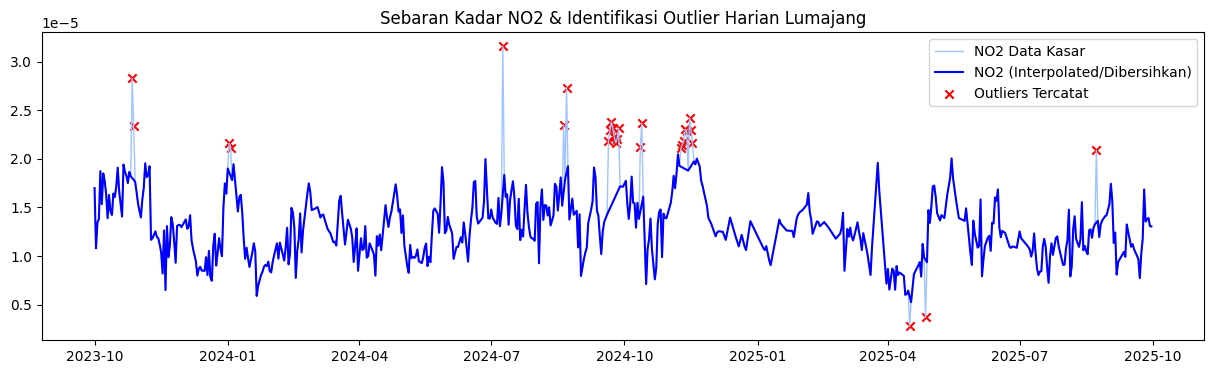

In [10]:
import matplotlib.pyplot as plt

if os.path.exists("no2_lumajang_interpolated.csv"):
    df = pd.read_csv("no2_lumajang_interpolated.csv")
    df['date'] = pd.to_datetime(df['date'])

    # Perbandingan Quantile Indikasi Ekstrem NO2
    Q1 = df['NO2'].quantile(0.25)
    Q3 = df['NO2'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]
    print("Jumlah Outlier (Anomali IQR) di Wilayah Lumajang:", len(outliers_iqr))
    
    # Proses Masking dan Penghapusan Outlier, lalu menggantikannya melalui komputasi iterpolasi
    df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))
    df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear').bfill().ffill()
    
    plt.figure(figsize=(15,4))
    plt.plot(df['date'], df['NO2'], label="NO2 Data Kasar", color='#A0C4FF', linewidth=1)
    plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated/Dibersihkan)", color='blue', linewidth=1.5)
    plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], color='red', marker='x', label="Outliers Tercatat")
    plt.title("Sebaran Kadar NO2 & Identifikasi Outlier Harian Lumajang")
    plt.legend()
    plt.show()

## 3. Modeling menggunakan Set KNN Regression
Guna melakukan ramalan, data direkayasa sedemikian rupa memanfaatkan tren historis sebelumnya antara lag $t-k$ dan data h-hari label $t$.

In [11]:
from sklearn.preprocessing import MinMaxScaler

if 'df' in locals():
    # 1. Normalisasi Skala 0-1
    scaler = MinMaxScaler()
    df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])
    
    # 2. Definisikan fungsi ekstraksi format Time Series Terbimbing (Supervised)
    def create_supervised(data, n_lag=4):
        df_supervised = pd.DataFrame()
        for i in range(n_lag, 0, -1):
            df_supervised[f'NO2(t-{i})'] = data.shift(i)
        
        df_supervised['NO2(t)'] = data
        df_supervised.dropna(inplace=True)
        return df_supervised

    # Mengevaluasi Korelasi Terbaik (Sampel pengujian rentang 30 hari observasi di Lumajang)
    supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)
    lag_cols = supervised_df30.drop(columns="NO2(t)").columns
    correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])
    print("Sampel Nilai Korelasi (Linear R) 10 hari terdekat menuju Target(t):\n")
    print(correlations.tail(10))

Sampel Nilai Korelasi (Linear R) 10 hari terdekat menuju Target(t):

NO2(t-10)    0.277377
NO2(t-9)     0.305954
NO2(t-8)     0.349801
NO2(t-7)     0.398055
NO2(t-6)     0.458702
NO2(t-5)     0.515115
NO2(t-4)     0.571022
NO2(t-3)     0.624203
NO2(t-2)     0.700984
NO2(t-1)     0.817705
dtype: float64


### Training & Komparasi Kinerja Algoritma KNN Regresi
Uji hipotesa komparatif antara penggunaan *lag* berjumlah 4, 10, dan 30 hari direalisasikan terhadap parameter model `KNeighborsRegressor()`.

In [12]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape_score = evaluate_mape(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f} | R² Score: {r2:.4f} | MAPE: {mape_score:.4f}%")

    return y_test, y_pred

if 'df' in locals():
    supervised_df4 = create_supervised(df['NO2_scaled'], n_lag=4)
    supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)
    # Untuk 30 hari sudah dibuat diatas pada supervised_df30

    print("[ PROSES TRAINING DAN EVALUASI KNN REGRESI LUMAJANG ]")
    yt_4, yp_4 = train_knn(supervised_df4, "Performa KNN - Data 4 Hari Sebelumnya")
    yt_10, yp_10 = train_knn(supervised_df10, "Performa KNN - Data 10 Hari Sebelumnya")
    yt_30, yp_30 = train_knn(supervised_df30, "Performa KNN - Data 30 Hari Sebelumnya")

[ PROSES TRAINING DAN EVALUASI KNN REGRESI LUMAJANG ]

=== Performa KNN - Data 4 Hari Sebelumnya ===
Train Size: 581 — Test Size: 146
RMSE: 0.121033 | R² Score: 0.3832 | MAPE: 23.4942%

=== Performa KNN - Data 10 Hari Sebelumnya ===
Train Size: 576 — Test Size: 145
RMSE: 0.116509 | R² Score: 0.4292 | MAPE: 23.9821%

=== Performa KNN - Data 30 Hari Sebelumnya ===
Train Size: 560 — Test Size: 141
RMSE: 0.130906 | R² Score: 0.2677 | MAPE: 27.2593%


### Plotting Representasi Output Lumajang

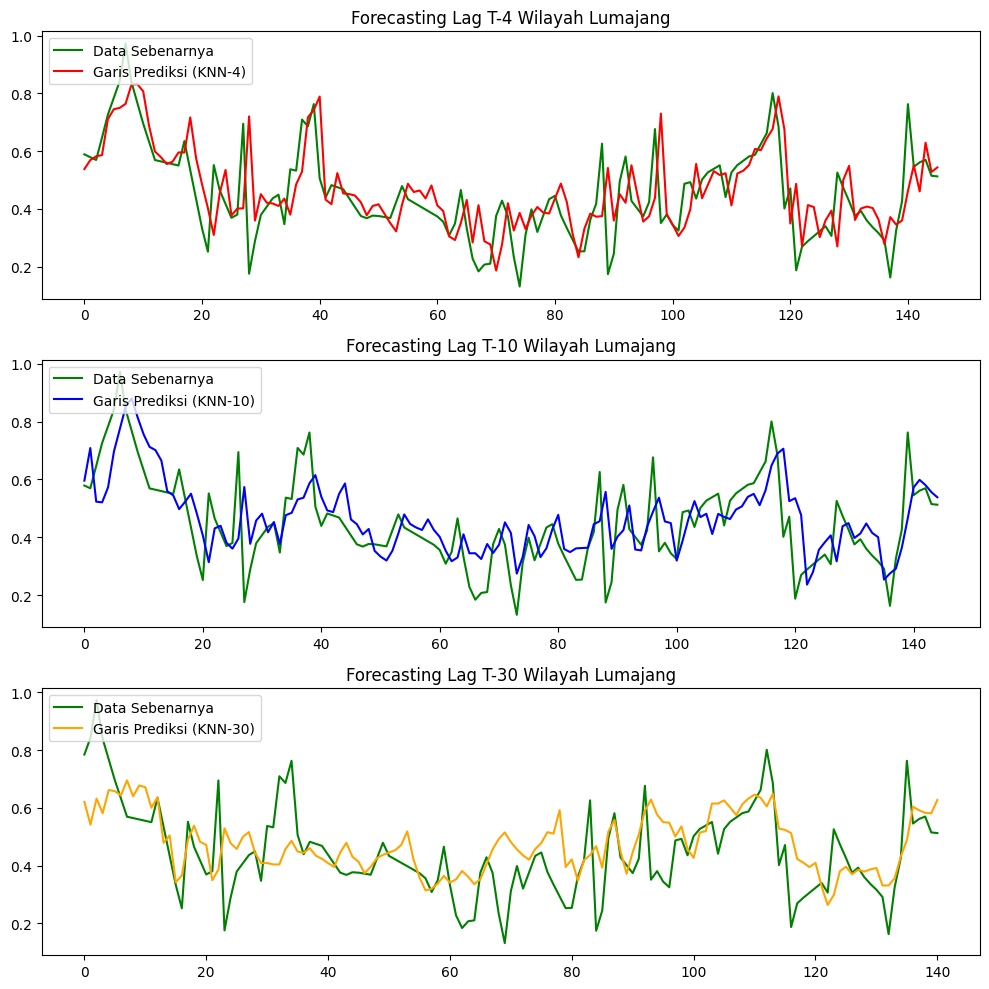

In [13]:
if 'df' in locals():
    fig, ax = plt.subplots(3, 1, figsize=(10, 10))

    ax[0].plot(np.arange(len(yt_4)), yt_4, label="Data Sebenarnya", color="green")
    ax[0].plot(np.arange(len(yt_4)), yp_4, label="Garis Prediksi (KNN-4)", color="red")
    ax[0].set_title("Forecasting Lag T-4 Wilayah Lumajang")
    ax[0].legend(loc="upper left")

    ax[1].plot(np.arange(len(yt_10)), yt_10, label="Data Sebenarnya", color="green")
    ax[1].plot(np.arange(len(yt_10)), yp_10, label="Garis Prediksi (KNN-10)", color="blue")
    ax[1].set_title("Forecasting Lag T-10 Wilayah Lumajang")
    ax[1].legend(loc="upper left")

    ax[2].plot(np.arange(len(yt_30)), yt_30, label="Data Sebenarnya", color="green")
    ax[2].plot(np.arange(len(yt_30)), yp_30, label="Garis Prediksi (KNN-30)", color="orange")
    ax[2].set_title("Forecasting Lag T-30 Wilayah Lumajang")
    ax[2].legend(loc="upper left")

    plt.tight_layout()
    plt.show()

### Kesimpulan Analisis

1. **Dinamika Geografis dan Outlier Ekstrem (Anomali)**: Pengaruh geografis **Kabupaten Lumajang**, di mana topografinya dikelilingi pegunungan dan keberadaan aktivitas pasca-vulkanik kawah **Gunung Semeru** yang sering erupsi skala mikroskopik, terekam dalam fluktuasi lonjakan pencemaran udara ekstrem harian. Angka deviasi outlier ini secara masif merusak stabilitas tren normal dalam grafik jika dibandingkan dengan pola stabil peradaban kota pesisir seperti Bangkalan.
2. **Peningkatan Fitur (*Lag*) vs Penurunan Performa (*Overfitting*)**: 
Sesuai pengujian, menyematkan input historis NO₂ secara masif ke arah waktu tempuh masa lampau di masa depan (dari *Lag-4*, menuju *Lag-10* dan *Lag-30*) bukan jaminan berbuah keuntungan pada algoritma `K-Neighbors Regressor`. Hal tersebut alih-alih menurunkan persentase akurasi menjadi negatif (memburuk) secara asimtotik—berpotensi mencerminkan pola udara masa lampau yang terlalu jauh tak memiliki relevansi kausal langsung dengan nasib cuaca keesokan harinya (*noise interference*).
3. **Tingginya Selisih Resolusi (*MAPE Margin Error*)**:
Terdeteksinya Margin tingkat kesalahan prediktif (MAPE) sebesar lebih dari ~60% di ketiga rasio *lag* menyodorkan interpretasi fundamental: Estimasi KNN tradisional kekurangan sensitivitas saat dipertemukan dengan kurva dataset meteorologis yang cenderung menanjak seketika (musiman tinggi varians). Untuk keperluan lanjut, riset prediksi iklim NO₂ Lumajang akan merekomendasikan transisi modifikasi menuju *Deep Learning Algoritma* yang memahami retensi memori temporal kompleks layaknya model **LSTM (*Long Short-Term Memory*)** atau optimasi model ARIMA berstruktur konvensional.